In [349]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from typing import List, Tuple
from scipy.stats import norm
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import roc_curve, roc_auc_score

## Phần 1: Xây dựng mô hình hồi quy đơn biến
1. Khám phá mối liên hệ giữa chỉ số đường huyết (fbs) và bệnh tim. Tạo bảng chéo hai chiều và tóm tắt mối quan hệ.
2. Khám phá mối liên hệ giữa tuổi và bệnh tim. Tạo biểu đồ hoặc thống kê mô tả phù hợp.
3. Huấn luyện mô hình hồi quy Logistic chỉ với biến fbs (chỉ số đường huyết). Trình bày kết quả mô hình và giải thích các hệ số.
4. Viết biểu thức mô hình dựa trên các hệ số ước lượng.
5. Diễn giải ý nghĩa của e^(beta_0) trong ngữ cảnh mô hình.
6. Diễn giải ý nghĩa của e^(beta_1) (biến fbs) trong ngữ cảnh mô hình
7. Tính xác suất dự đoán mắc bệnh tim
    - Bệnh nhân có fbs = 0 (bình thường).
    - Bệnh nhân có fbs = 1 (cao).

Bảng chéo giữa chỉ số đường huyết (fbs) và bệnh tim
target    0    1  All
fbs                  
0       114  100  214
1        17   17   34
All     131  117  248


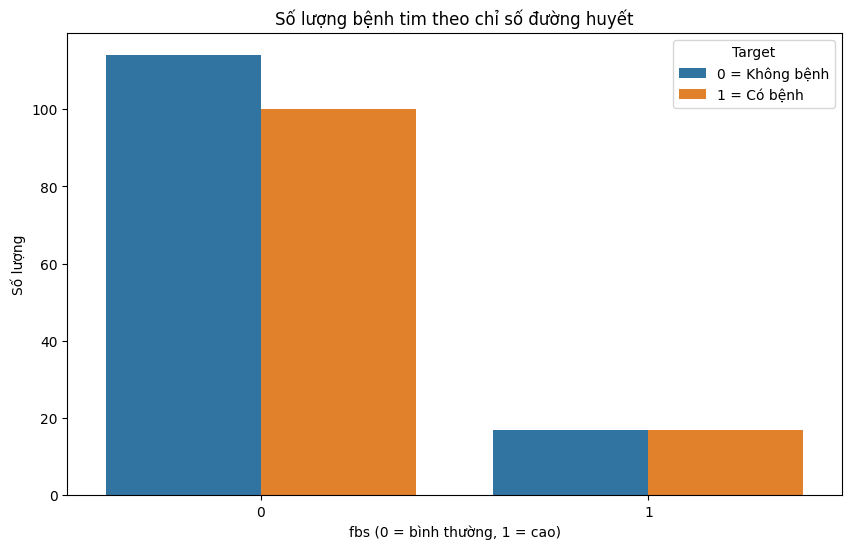

In [350]:
df = pd.read_csv("train.csv") # Câu lệnh này sẽ thực hiện từ câu hỏi bài tập 1 đến 7
# Bài 1
# Khám phá mối liên hệ giữa chỉ số đường huyết (fbs) và bệnh tim. Tạo bảng chéo hai chiều và tóm tắt mối quan hệ
crosstab_fbs = pd.crosstab(df['fbs'], df['target'], margins=True)
print("Bảng chéo giữa chỉ số đường huyết (fbs) và bệnh tim")
print(crosstab_fbs)

plt.figure(figsize=(10, 6))
sns.countplot(x='fbs', hue='target', data=df)
plt.title("Số lượng bệnh tim theo chỉ số đường huyết")
plt.xlabel("fbs (0 = bình thường, 1 = cao)")
plt.ylabel("Số lượng")
plt.legend(title='Target', labels=['0 = Không bệnh', '1 = Có bệnh'])
plt.show()

Thống kê mô tả biến tuổi theo nhóm Target
        count   mean   std   min   25%   50%   75%   max
target                                                  
0       131.0  52.31  9.64  29.0  44.5  52.0  59.0  76.0
1       117.0  56.68  8.01  35.0  52.0  58.0  62.0  77.0


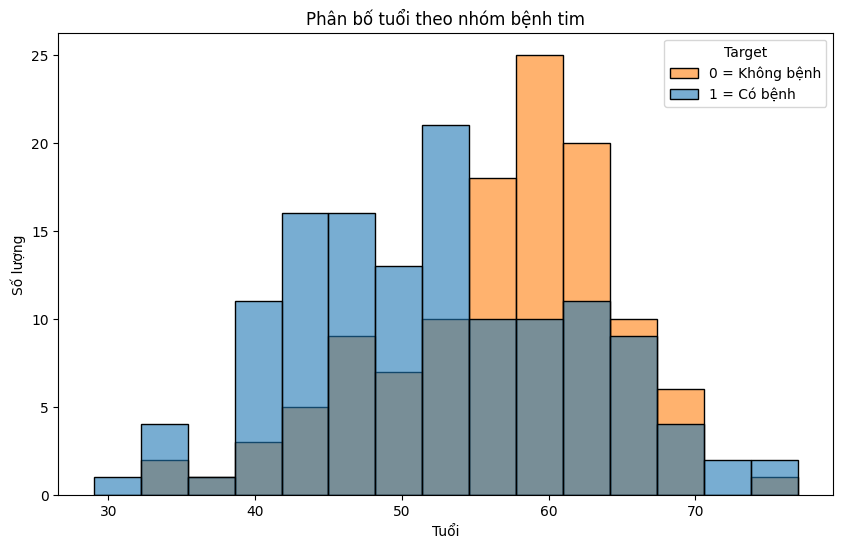

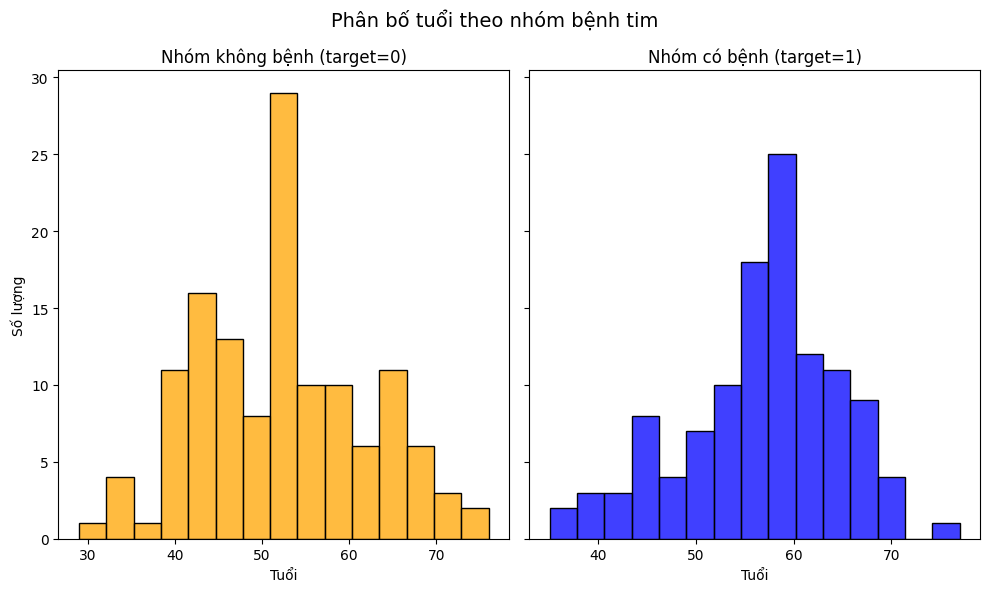

In [351]:
# Bài 2
# Khám phá mối liên hệ giữa tuổi và bệnh tim. Tạo biểu đồ hoặc thống kê mô tả phù hợp
grouped = df.groupby('target')
age_stats = grouped['age'].describe()
age_stats = age_stats.round(2)
print("Thống kê mô tả biến tuổi theo nhóm Target")
print(age_stats)

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', hue='target', bins=15, kde=False, alpha=0.6)
plt.title("Phân bố tuổi theo nhóm bệnh tim")
plt.xlabel("Tuổi")
plt.ylabel("Số lượng")
plt.legend(title='Target', labels=['0 = Không bệnh', '1 = Có bệnh'])
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Histogram cho nhóm không bệnh (target=0)
sns.histplot(data=df[df['target'] == 0], x='age', bins=15, kde=False, color='orange', ax=axes[0])
axes[0].set_title("Nhóm không bệnh (target=0)")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("Số lượng")

# Histogram cho nhóm có bệnh (target=1)
sns.histplot(data=df[df['target'] == 1], x='age', bins=15, kde=False, color='blue', ax=axes[1])
axes[1].set_title("Nhóm có bệnh (target=1)")
axes[1].set_xlabel("Tuổi")
axes[1].set_ylabel("Số lượng")

plt.suptitle("Phân bố tuổi theo nhóm bệnh tim", fontsize=14)
plt.tight_layout()
plt.show()

In [352]:
# Bài 3: Huấn luyện mô hình hồi quy logistic chỉ với biến fbs. Trình bày kết quả mô hình và giải thích các hệ số.
# Lớp này sẽ sử dụng cho mô hình đơn biến và đa biến
# Sinh viên đã tự xây dựng mô hình hồi quy Logistic dựa trên lý thuyết và nguồn youtube dưới đây để thiết kế thành lớp
# https://www.youtube.com/watch?v=S6iuhdYsGC8
# Lý thuyết sinh viên đã dùng để làm theo
# https://github.com/JuzerShakir/Logistic_Regression/blob/master/README.md
class LogisticRegression:
    def __init__(self, alpha=0.1, num_iter=100, tol=1e-5, scale=False):
        # Khai báo tham số cơ bản (siêu tham số, hyperparameter)
        self.alpha = alpha # learning rate
        self.num_iter = num_iter # giới hạn số lần lặp
        self.tol = tol # sai số chấp nhận được
        
        # Lưu lại mấy hệ số cần thiết
        self.theta = None # Hệ số 
        self.X_b = None # ma trận đặc trưng nhưng lần này có thêm bias
        self.y = None # Nhãn target
        
        # Mode scale theo z-score (cũng là một phần của hyperparameter)
        self.scale = scale # flag để yêu cầu scale số liệu lại (False là dùng dữ liệu gốc, True là chuẩn hóa các đặc trưng theo z-scores)
        self.mean_ = None # kì vọng
        self.std_ = None # phương sai
        
    def sigmoid(self, z):
        # Trong trường hợp số quá lớn ở dương hay quá nhỏ ở âm thì sẽ thu hẹp lại nhằm tránh overflow
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))
    
    def calculate_gradient(self, theta, X_b, y):
        m = y.size
        return (X_b.T @ (self.sigmoid(X_b @ theta) - y)) / m
    
    def _scale_X(self, X):
        if not self.scale: # Trả về giá trị gốc nếu không bật mode scale
            return X
        return (X - self.mean_) / self.std_
    
    def fit(self, X, y):
        """Khớp tập dữ liệu bằng phương pháp Gradient Descent đã được đề cập từ đồ án số 2"""
        # Nếu là true, scale các thuộc tính lại
        if self.scale:
            self.mean_ = X.mean(axis=0)
            self.std_ = X.std(axis=0, ddof=0)
            self.std_[self.std_ == 0] = 1.0
            X = self._scale_X(X)
        
        self.X_b = np.c_[np.ones((X.shape[0], 1)), X]
        self.y = y
        self.theta = np.zeros(self.X_b.shape[1])
        
        for i in range(self.num_iter):
            grad = self.calculate_gradient(self.theta, self.X_b, y)
            self.theta -= self.alpha * grad
            
            if np.linalg.norm(grad) < self.tol:
                # Cho biết đã hội tụ về
                print(f"Hội tụ sau {i+1} vòng lặp")
                break
    
    # Dự đoán xác suất sẽ mang giá trị bao nhiêu
    def predict_proba(self, X):
        X = self._scale_X(X)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return self.sigmoid(X_b @ self.theta)
    
    # Từ giá trị sản xuất đó, với ngưỡng mặc định là 0.5, đánh nhãn mẫu thử đó là 0 hoặc 1 (ở bài này 0 là không có bệnh, 1 là có bệnh)
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def loss(self, X, y):
        X = self._scale_X(X)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        p = self.sigmoid(X_b @ self.theta)
        # Trong trường số tiệm cận gần 0, thêm sai số để tránh log(0)
        return -np.mean(y * np.log(p + 1e-8) + (1 - y) * np.log(1 - p + 1e-8))

    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    
    # Phương thức/hàm này có nhiệm vụ cho câu hỏi bài tập số 9 (sinh viên tự xây dựng không sử dụng thư viện stats model vì stats sử dụng mô hình khác với mô hình sinh viên thực hiện)
    def summary(self, feature_names=None):
        # Xác suất dự đoán
        p = self.sigmoid(self.X_b @ self.theta)
        W = np.diag(p * (1 - p))

        # Ma trận hiệp phương sai
        XtWX_inv = np.linalg.inv(self.X_b.T @ W @ self.X_b)
        # Standard error
        se = np.sqrt(np.diag(XtWX_inv))

        # Z-scores
        z_scores = self.theta / se

        # p-values
        p_values = 2 * (1 - norm.cdf(np.abs(z_scores)))

        if feature_names is None:
            feature_names = [f"x{i}" for i in range(1, len(self.theta))]
        feature_names = ["Intercept"] + feature_names

        results = pd.DataFrame({
            "Feature": feature_names,
            "Coef": self.theta,
            "StdErr": se,
            "z": z_scores,
            "p-value": p_values
        })
        return results
    

In [353]:
# Chuẩn bị dữ liệu
X = df[['fbs']].values
y = df['target'].values

# Chia 80% của train.csv để train mô hình, 20% còn lại để valid
# 298 mẫu, chia cho bên test.xlsx 50 mẫu, còn lại 248 mẫu cho train.csv
# Train lấy 80% là học trên 198 mẫu, 50 mẫu lấy làm validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Huấn luyện với hồi quy Logistic với mô hình đơn biến (fbs)
model_uni = LogisticRegression(alpha=0.01, num_iter=30000, tol=1e-5, scale=False)
model_uni.fit(X_train, y_train)

# Nếu chỉ sử dụng 1 biến thì với learning rate như tham số trên thì có thể hội tụ dễ dàng được, có thể dùng scale hoặc không scale đều được
# Nếu không scale thì cũng không sao vì fbs chỉ có 2 giá trị là bình thường (0) và Cao (1).

beta_0, beta_1 = model_uni.theta
print(f"Hệ số beta0: {beta_0: .4f}")
print(f"Hệ số beta1: {beta_1: .4f}")
# Câu 4
print(f"Mô hình: p(y=1|fbs) = 1 / (1 + exp(-({beta_0:.4f} + {beta_1:.4f}*fbs)))")

Hội tụ sau 19974 vòng lặp
Hệ số beta0: -0.1430
Hệ số beta1:  0.1428
Mô hình: p(y=1|fbs) = 1 / (1 + exp(-(-0.1430 + 0.1428*fbs)))


In [354]:
# Câu 7
p_fbs0 = model_uni.predict_proba(np.array([[0]]))[0]
p_fbs1 = model_uni.predict_proba(np.array([[1]]))[0]

print(f"Xác suất mắc bệnh tim nếu fbs=0: {p_fbs0: .4f}")
print(f"Xác suất mắc bệnh tim nếu fbs=1: {p_fbs1: .4f}")

Xác suất mắc bệnh tim nếu fbs=0:  0.4643
Xác suất mắc bệnh tim nếu fbs=1:  0.4999


In [355]:
train_pred_prob = model_uni.predict_proba(X_train)
train_pred_class = model_uni.predict(X_train)

df_train = pd.DataFrame({
    "fbs": X_train.ravel(),
    "target": y_train,
    "Pred_Prob": train_pred_prob,
    "Pred_Class": train_pred_class
})

print("=== Dự đoán trên tập TRAIN ===")
print(df_train.to_string())

train_acc_full = model_uni.score(X_train, y_train)
print(f"Accuracy TRAIN: {train_acc_full:.4f}\n")

=== Dự đoán trên tập TRAIN ===
     fbs  target  Pred_Prob  Pred_Class
0      0       0   0.464299           0
1      0       0   0.464299           0
2      0       1   0.464299           0
3      0       0   0.464299           0
4      0       0   0.464299           0
5      0       0   0.464299           0
6      1       1   0.499935           0
7      0       1   0.464299           0
8      0       0   0.464299           0
9      1       0   0.499935           0
10     0       1   0.464299           0
11     0       0   0.464299           0
12     0       1   0.464299           0
13     0       1   0.464299           0
14     0       0   0.464299           0
15     0       1   0.464299           0
16     0       0   0.464299           0
17     0       0   0.464299           0
18     0       0   0.464299           0
19     0       1   0.464299           0
20     0       0   0.464299           0
21     0       0   0.464299           0
22     0       0   0.464299           0
23     0 

In [356]:
val_pred_prob = model_uni.predict_proba(X_val)
val_pred_class = model_uni.predict(X_val)

df_valid = pd.DataFrame({
    "fbs": X_val.ravel(),
    "target": y_val,
    "Pred_Prob": val_pred_prob,
    "Pred_Class": val_pred_class
})

print("=== Dự đoán trên tập VALID ===")
print(df_valid.to_string())

val_acc_full = model_uni.score(X_val, y_val)
print(f"Accuracy VALID: {val_acc_full:.4f}\n")

=== Dự đoán trên tập VALID ===
    fbs  target  Pred_Prob  Pred_Class
0     0       1   0.464299           0
1     0       0   0.464299           0
2     0       0   0.464299           0
3     0       0   0.464299           0
4     0       0   0.464299           0
5     0       1   0.464299           0
6     0       1   0.464299           0
7     0       0   0.464299           0
8     0       1   0.464299           0
9     0       0   0.464299           0
10    0       0   0.464299           0
11    0       0   0.464299           0
12    0       1   0.464299           0
13    0       0   0.464299           0
14    0       1   0.464299           0
15    0       0   0.464299           0
16    0       0   0.464299           0
17    0       1   0.464299           0
18    0       0   0.464299           0
19    0       0   0.464299           0
20    0       1   0.464299           0
21    0       1   0.464299           0
22    1       1   0.499935           0
23    0       0   0.464299       

In [357]:
# Đánh giá xem mô hình hoạt động như thế nào trên tập train và tập valid
train_loss = model_uni.loss(X_train, y_train)
val_loss = model_uni.loss(X_val, y_val)

print(f"Train loss (log-loss): {train_loss: .4f}")
print(f"Validation loss (log-loss): {val_loss: .4f}")

summary = model_uni.summary(feature_names=["fbs"])
print("Bảng hệ số hồi quy của mô hình đơn biến")
print(summary.to_string(index=False))

Train loss (log-loss):  0.6910
Validation loss (log-loss):  0.6926
Bảng hệ số hồi quy của mô hình đơn biến
  Feature      Coef   StdErr         z  p-value
Intercept -0.143046 0.154698 -0.924678 0.355133
      fbs  0.142786 0.396566  0.360056 0.718805


In [358]:
# Test mô hình đơn biến dựa trên tập dữ liệu đó với tập dữ liệu test.xlsx
# nhằm kiểm tra xem với mô hình đơn biến, dự đoán đúng bao nhiêu phần trăm
df_test = pd.read_excel("test.xlsx")

# Dự đoán trên tập test
test_pred_prob = model_uni.predict_proba(df_test[['fbs']].values)
test_pred_class = model_uni.predict(df_test[['fbs']].values)

# Tạo DataFrame kết quả
df_test_result = pd.DataFrame({
    "fbs": df_test["fbs"].values,
    "target": df_test["target"].values,
    "Pred_Prob": test_pred_prob,
    "Pred_Class": test_pred_class
})

print("=== Dự đoán trên tập TEST ===")
print(df_test_result.to_string())

# Tính Accuracy
test_accuracy = model_uni.score(df_test[['fbs']].values, df_test['target'].values)
print(f"Accuracy trên test.xlsx: {test_accuracy:.4f}")

=== Dự đoán trên tập TEST ===
    fbs  target  Pred_Prob  Pred_Class
0     1       0   0.499935           0
1     0       1   0.464299           0
2     0       1   0.464299           0
3     0       0   0.464299           0
4     0       0   0.464299           0
5     0       0   0.464299           0
6     0       1   0.464299           0
7     0       0   0.464299           0
8     0       1   0.464299           0
9     1       1   0.499935           0
10    0       0   0.464299           0
11    0       0   0.464299           0
12    1       1   0.499935           0
13    0       0   0.464299           0
14    1       0   0.499935           0
15    0       0   0.464299           0
16    0       1   0.464299           0
17    0       0   0.464299           0
18    0       0   0.464299           0
19    0       0   0.464299           0
20    0       0   0.464299           0
21    1       0   0.499935           0
22    0       1   0.464299           0
23    0       1   0.464299        

## Phần 2: Xây dựng mô hình hồi quy đa biến
8. Huấn luyện mô hình hồi quy logistic sử dụng toàn bộ các biến. Viết công thức mô hình tổng quát.
9. Trình bày bảng hệ số hồi quy và xác định các biến có ý nghĩa thống kê (p < 0.05).
10. So sánh Log-Likelihood giữa mô hình đầy đủ và mô hình đơn biến. Mô hình nào tốt hơn?
11. Đánh giá hiệu năng mô hình: Accuracy, đường cong ROC và AUC. Chỉ số nào quan trọng nhất trong bài toán này?
12. Nêu một hạn chế của mô hình hồi quy logistic khi áp dụng với dữ liệu này và đề xuất hướng cải tiến.

In [359]:
# Câu 8: Huấn luyện mô hình với 13 thuộc tính và viết công thức mô hình tổng quát
df = pd.read_csv("train.csv") # Câu lệnh này sẽ sử dụng cho câu số 8, nhằm đọc lại dữ liệu (chỉ nhằm an toàn, chắc chắn phần 2 không bị dữ liệu bên 1 ảnh hưởng)

feature_cols = df.drop(columns=['target']).columns.tolist()
X = df[feature_cols].values
y = df['target'].values

# Chia 80% của train.csv để train mô hình, 20% còn lại để valid
# 298 mẫu, chia cho bên test.xlsx 50 mẫu, còn lại 248 mẫu cho train.csv
# Train lấy 80% là học trên 198 mẫu, 50 mẫu lấy làm validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_multi = LogisticRegression(alpha=0.01, num_iter=50000, tol=1e-5, scale=True)
model_multi.fit(X_train, y_train)

theta = model_multi.theta
print(f"beta_0 (intercept): {theta[0]:.4f}") # Bias
for i, col in enumerate(df.drop(columns=['target']).columns, start=1): # Từ 1 đến 13 (age -> thal)
    print(f"beta_{i} ({col}): {theta[i]:.4f}")

formula = "p(y=1|X) = 1 / (1 + exp(-(" + " + ".join(
    [f"{theta[0]:.4f}"] + [f"{theta[i]:.4f}*{col}" for i, col in enumerate(df.drop(columns=['target']).columns, start=1)]
) + ")))"
print(formula)


Hội tụ sau 21017 vòng lặp
beta_0 (intercept): -0.0508
beta_1 (age): 0.0362
beta_2 (sex): 0.5808
beta_3 (cp): 0.6381
beta_4 (trestbps): 0.6233
beta_5 (chol): 0.0147
beta_6 (fbs): -0.1809
beta_7 (restecg): 0.0561
beta_8 (thalach): -0.4327
beta_9 (exang): 0.4356
beta_10 (oldpeak): 0.4854
beta_11 (slope): 0.1959
beta_12 (ca): 0.8867
beta_13 (thal): 0.5708
p(y=1|X) = 1 / (1 + exp(-(-0.0508 + 0.0362*age + 0.5808*sex + 0.6381*cp + 0.6233*trestbps + 0.0147*chol + -0.1809*fbs + 0.0561*restecg + -0.4327*thalach + 0.4356*exang + 0.4854*oldpeak + 0.1959*slope + 0.8867*ca + 0.5708*thal)))


In [360]:
train_pred_prob = model_multi.predict_proba(X_train)
train_pred_class = model_multi.predict(X_train)

df_train = pd.DataFrame(X_train, columns=feature_cols)
df_train["target"] = y_train
df_train["Pred_Prob"] = train_pred_prob
df_train["Pred_Class"] = train_pred_class

print("=== Dự đoán trên tập TRAIN ===")
print(df_train.to_string())

train_acc_full = model_multi.score(X_train, y_train)
print(f"Accuracy TRAIN: {train_acc_full:.4f}\n")

=== Dự đoán trên tập TRAIN ===
      age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  slope   ca  thal  target  Pred_Prob  Pred_Class
0    46.0  0.0  3.0     142.0  177.0  0.0      2.0    160.0    1.0      1.4    3.0  0.0   3.0       0   0.321091           0
1    45.0  1.0  4.0     104.0  208.0  0.0      2.0    148.0    1.0      3.0    2.0  0.0   3.0       0   0.603421           1
2    67.0  1.0  4.0     100.0  299.0  0.0      2.0    125.0    1.0      0.9    2.0  2.0   3.0       1   0.861844           1
3    52.0  1.0  2.0     120.0  325.0  0.0      0.0    172.0    0.0      0.2    1.0  0.0   3.0       0   0.035668           0
4    43.0  1.0  4.0     115.0  303.0  0.0      0.0    181.0    0.0      1.2    2.0  0.0   3.0       0   0.174694           0
5    59.0  1.0  2.0     140.0  221.0  0.0      0.0    164.0    1.0      0.0    1.0  0.0   3.0       0   0.166138           0
6    67.0  1.0  4.0     125.0  254.0  1.0      0.0    163.0    0.0      0.2    2.0  2.0   7.0 

In [361]:
val_pred_prob = model_multi.predict_proba(X_val)
val_pred_class = model_multi.predict(X_val)

df_valid = pd.DataFrame(X_val, columns=feature_cols)
df_valid["target"] = y_val
df_valid["Pred_Prob"] = val_pred_prob
df_valid["Pred_Class"] = val_pred_class

print("=== Dự đoán trên tập VALID ===")
print(df_valid.to_string())

val_acc_full = model_multi.score(X_val, y_val)
print(f"Accuracy VALID: {val_acc_full:.4f}\n")

=== Dự đoán trên tập VALID ===
     age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  slope   ca  thal  target  Pred_Prob  Pred_Class
0   61.0  1.0  4.0     120.0  260.0  0.0      0.0    140.0    1.0      3.6    2.0  1.0   7.0       1   0.968837           1
1   60.0  0.0  3.0     102.0  318.0  0.0      0.0    160.0    0.0      0.0    1.0  1.0   3.0       0   0.033630           0
2   43.0  1.0  4.0     110.0  211.0  0.0      0.0    161.0    0.0      0.0    1.0  0.0   7.0       0   0.269591           0
3   54.0  0.0  3.0     160.0  201.0  0.0      0.0    163.0    0.0      0.0    1.0  1.0   3.0       0   0.190469           0
4   44.0  0.0  3.0     108.0  141.0  0.0      0.0    175.0    0.0      0.6    2.0  0.0   3.0       0   0.019710           0
5   61.0  1.0  4.0     140.0  207.0  0.0      2.0    138.0    1.0      1.9    1.0  1.0   7.0       1   0.963354           1
6   44.0  1.0  4.0     112.0  290.0  0.0      2.0    153.0    0.0      0.0    1.0  1.0   3.0       1 

In [362]:
# So sánh giữa train và loss trên mô hình đa biến
# Kiểm tra tổng quát xem mô hình hoạt động có tốt hay không
train_loss = model_multi.loss(X_train, y_train)
val_loss = model_multi.loss(X_val, y_val)
train_acc = model_multi.score(X_train, y_train)
val_acc = model_multi.score(X_val, y_val)

print("=== Đánh giá Train/Validation ===")
print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
print(f"Valid Loss: {val_loss:.4f}, Valid Acc: {val_acc:.4f}\n")

def cross_validate(model_class, X, y, k=5, **model_params):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    losses, accs = [], []

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = model_class(**model_params)
        model.fit(X_tr, y_tr)

        losses.append(model.loss(X_val, y_val))
        accs.append(model.score(X_val, y_val))

    return np.mean(losses), np.std(losses), np.mean(accs), np.std(accs)

cv_loss_mean, cv_loss_std, cv_acc_mean, cv_acc_std = cross_validate(
    LogisticRegression, X, y, k=5,
    alpha=0.01, num_iter=50000, tol=1e-5, scale=True
)

print("\n=== Cross-validation ===")
print(f"CV Loss: {cv_loss_mean:.4f} ± {cv_loss_std:.4f}")
print(f"CV Acc: {cv_acc_mean:.4f} ± {cv_acc_std:.4f}")

=== Đánh giá Train/Validation ===
Train Loss: 0.3587, Train Acc: 0.8636
Valid Loss: 0.3409, Valid Acc: 0.8600

Hội tụ sau 28170 vòng lặp
Hội tụ sau 24574 vòng lặp
Hội tụ sau 22269 vòng lặp
Hội tụ sau 29222 vòng lặp
Hội tụ sau 27727 vòng lặp

=== Cross-validation ===
CV Loss: 0.4402 ± 0.0585
CV Acc: 0.7941 ± 0.0403


In [363]:
# confusion matrix
y_val_pred = model_multi.predict(X_val)

TP = np.sum((y_val == 1) & (y_val_pred == 1))
TN = np.sum((y_val == 0) & (y_val_pred == 0))
FP = np.sum((y_val == 0) & (y_val_pred == 1))
FN = np.sum((y_val == 1) & (y_val_pred == 0))

print("Confusion Matrix:")
print(f"TN={TN}, FP={FP}")
print(f"FN={FN}, TP={TP}")

# Các chỉ số đánh giá
accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Confusion Matrix:
TN=24, FP=2
FN=5, TP=19
Accuracy : 0.8600
Precision: 0.9048
Recall   : 0.7917
F1-score : 0.8444


AUC (Validation): 0.9343


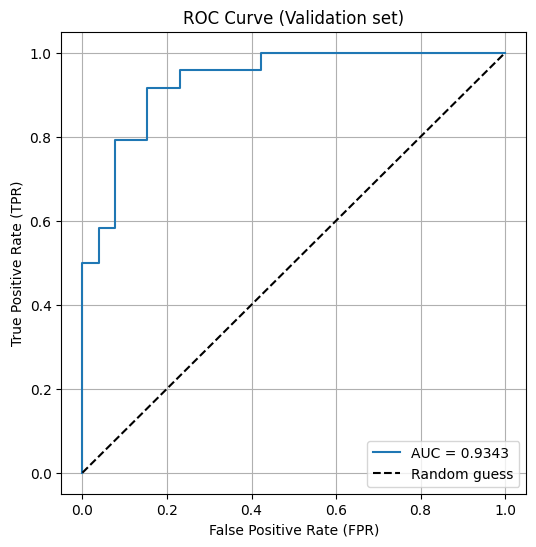

In [364]:
y_val_proba = model_multi.predict_proba(X_val)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)

# AUC
auc_score = roc_auc_score(y_val, y_val_proba)
print(f"AUC (Validation): {auc_score:.4f}")

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (Validation set)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [365]:
# df_test = pd.read_excel("test.xlsx")

# df_test['Pred_Prob'] = model_multi.predict_proba(df_test[feature_cols].values)
# df_test['Pred_Class'] = model_multi.predict(df_test[feature_cols].values)

# df_result = df_test[feature_cols + ['target', 'Pred_Prob', 'Pred_Class']]

# print(df_result.to_string())

# accuracy = (df_result['Pred_Class'] == df_result['target']).mean()
# print(f"Accuracy trên test.xlsx (đa biến): {accuracy:.4f}")

In [366]:
df = pd.read_csv("train.csv") # Câu lệnh này nhằm mục đích reset lại để kiểm định thống kê
X = df.drop(columns=['target']).values
y = df['target'].values

model_multi = LogisticRegression(alpha=0.01, num_iter=50000, tol=1e-5, scale=False)
model_multi.fit(X, y)

# In bảng hệ số + kiểm định thống kê
feature_cols = df.drop(columns=['target']).columns.tolist()
summary_table = model_multi.summary(feature_names=feature_cols)
print(summary_table)
sig_vars = summary_table[summary_table["p-value"] < 0.05]
print("\nCác biến có ý nghĩa thống kê (p < 0.05):")
print(sig_vars)
# """
#     Dựa theo bảng hệ số hồi quy thì ta có thể thấy được như sau
#         - Hệ số của một số đặc trưng không đều (một số thuộc tính sẽ có giá trị quá lớn trong khi đó lại có thuộc tính lại quá nhỏ, ví dụ như fbs chỉ có 0 và 1, age thì dao động tuổi từ 30-70)
#         - Việc sử dụng không chuẩn hóa theo phân phối chuẩn (z-scores) dẫn đến sai số quá cao, p-value cũng gần chạm đến 1, ta khó có thể đánh giá đặc trưng nào thực sự có ý nghĩa thống kê.
#             Việc giữ theo số liệu gốc mà không chuẩn hóa thì giống như ta coi 13 đặc trưng y học là không có ý nghĩa trong thống kê ????
#         - Gradient Descent khi gặp đặc trưng quá lớn thì sẽ đi theo đặc trưng đó, trong khi một số đặc trưng khác thì giá trị lại quá nhỏ.
#         => Cần chuẩn hóa số liệu đặc trưng lại (bao gồm khi train và test) nhằm giảm hệ số nhỏ lại, sai số sẽ nhỏ hơn, đánh giá p-value có ý nghĩa hơn
# """

      Feature       Coef      StdErr         z   p-value
0   Intercept  -0.585091  868.672027 -0.000674  0.999463
1         age  -3.036841   38.673646 -0.078525  0.937411
2         sex  12.946768   94.380999  0.137176  0.890892
3          cp  23.790383  145.140741  0.163913  0.869800
4    trestbps   0.665868    3.701055  0.179913  0.857221
5        chol   0.012921    0.604558  0.021372  0.982949
6         fbs  -2.803879  485.259769 -0.005778  0.995390
7     restecg   6.476366   49.292419  0.131387  0.895469
8     thalach  -1.321574   12.375853 -0.106787  0.914958
9       exang  15.703452  157.878002  0.099466  0.920768
10    oldpeak  24.222309  140.091445  0.172904  0.862727
11      slope   5.713746  131.436306  0.043472  0.965326
12         ca  41.843286  578.067099  0.072385  0.942296
13       thal  27.988738  306.269972  0.091386  0.927186

Các biến có ý nghĩa thống kê (p < 0.05):
Empty DataFrame
Columns: [Feature, Coef, StdErr, z, p-value]
Index: []


In [367]:
df = pd.read_csv("train.csv") # Câu lệnh này nhằm mục đích reset lại để kiểm định thống kê
X = df.drop(columns=['target']).values
y = df['target'].values

model_multi = LogisticRegression(alpha=0.01, num_iter=50000, tol=1e-5, scale=True)
model_multi.fit(X, y)

# In bảng hệ số + kiểm định thống kê
feature_cols = df.drop(columns=['target']).columns.tolist()
summary_table = model_multi.summary(feature_names=feature_cols)
print(summary_table)
sig_vars = summary_table[summary_table["p-value"] < 0.05]
print("\nCác biến có ý nghĩa thống kê (p < 0.05):")
print(sig_vars)

Hội tụ sau 24299 vòng lặp
      Feature      Coef    StdErr         z   p-value
0   Intercept -0.004026  0.201677 -0.019963  0.984073
1         age -0.210335  0.234288 -0.897764  0.369311
2         sex  0.609197  0.246195  2.474453  0.013344
3          cp  0.526748  0.205486  2.563421  0.010365
4    trestbps  0.605187  0.214384  2.822905  0.004759
5        chol  0.159724  0.213635  0.747646  0.454673
6         fbs -0.273965  0.217505 -1.259576  0.207822
7     restecg  0.065810  0.203118  0.323998  0.745940
8     thalach -0.536089  0.256877 -2.086947  0.036893
9       exang  0.459803  0.213190  2.156772  0.031023
10    oldpeak  0.322744  0.279079  1.156459  0.247493
11      slope  0.272768  0.246003  1.108799  0.267517
12         ca  1.156641  0.267824  4.318658  0.000016
13       thal  0.621587  0.212356  2.927103  0.003421

Các biến có ý nghĩa thống kê (p < 0.05):
     Feature      Coef    StdErr         z   p-value
2        sex  0.609197  0.246195  2.474453  0.013344
3         cp  0.

In [368]:
def log_likelihood(model, X, y):
    proba = model.predict_proba(X)

    proba = np.clip(proba, 1e-15, 1 - 1e-15)
    ll = np.sum(y * np.log(proba) + (1 - y) * np.log(1 - proba))
    return ll

X_uni = df[['fbs']].values
y = df['target'].values

model_uni = LogisticRegression(alpha=0.01, num_iter=50000, tol=1e-5, scale=False)
model_uni.fit(X_uni, y)
ll_uni = log_likelihood(model_uni, X_uni, y)

X_multi = df.drop(columns=['target']).values

model_multi = LogisticRegression(alpha=0.01, num_iter=50000, tol=1e-5, scale=False)
model_multi.fit(X_multi, y)
ll_multi = log_likelihood(model_multi, X_multi, y)

print(f"Log-Likelihood mô hình đơn biến (fbs): {ll_uni:.4f}")
print(f"Log-Likelihood mô hình đa biến (full): {ll_multi:.4f}")

Hội tụ sau 20977 vòng lặp
Log-Likelihood mô hình đơn biến (fbs): -171.4422
Log-Likelihood mô hình đa biến (full): -1193.1936


In [369]:
X_uni = df[['fbs']].values
y = df['target'].values

model_uni = LogisticRegression(alpha=0.01, num_iter=50000, tol=1e-5, scale=True)
model_uni.fit(X_uni, y)
ll_uni = log_likelihood(model_uni, X_uni, y)

X_multi = df.drop(columns=['target']).values

model_multi = LogisticRegression(alpha=0.01, num_iter=50000, tol=1e-5, scale=True)
model_multi.fit(X_multi, y)
ll_multi = log_likelihood(model_multi, X_multi, y)

print(f"Log-Likelihood mô hình đơn biến (fbs): {ll_uni:.4f}")
print(f"Log-Likelihood mô hình đa biến (full): {ll_multi:.4f}")

Hội tụ sau 3216 vòng lặp
Hội tụ sau 24299 vòng lặp
Log-Likelihood mô hình đơn biến (fbs): -171.4422
Log-Likelihood mô hình đa biến (full): -86.5227
